### GOAL 
Notebook aims to disentangle HGSOC RNA data into 2+ data spaces (Cell Cycle Signal Space, Inteferon Signal Space, Cell Dissociation Signal Space, Cell Type Signal Space)

In [1]:
import sys
import os

# Get the directory containing the notebook
NOTEBOOK_DIR = os.getcwd()

# Compute project root (go up one level)
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '../../'))

# Add project root to path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [3]:
from src.data.umi_data import UMIVaeDataset
from src.celluntangler import utils
from src.celluntangler.models import Trainer
from src.celluntangler.models.nb_vae import NBVAE
from src.visualization.helpers import split_embeddings
from src.visualization.visualization_functions import visualize_poincare_from_lorentz, visualize_embedding, visualize_2d

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# TODO - change path to actual data you care about
# TODO - debug getting HVG genes working with annotated dataframe
adata = sc.read_h5ad("../../../../data/hela/hela_select_with_phase.h5ad")

##### Is the matrix sparse?

### Sanity-Checking the Data

### Pre-processing

In [5]:
cell_cycle_genes_path = "../../../../genes/celluntangler_human_cell_cycle_genes.tsv"
cell_cycle_genes = pd.read_csv(cell_cycle_genes_path, header = None, sep="\t")

In [6]:
contained_genes_cc = adata.var["gene_symbols"].isin(cell_cycle_genes[0])

In [10]:
process_cc_indices = np.where(contained_genes_cc)[0]

all_known_indices = np.hstack((process_cc_indices)) # TODO - modify all_known indices based on experiment that is being run 
remaining_indices = np.setdiff1d(np.arange(adata.shape[1]), all_known_indices)

rearranged_indices = np.hstack((process_cc_indices, remaining_indices))
rearranged_indices = rearranged_indices.astype(int)

In [12]:
adata.var_names

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '4535', '4536', '4537', '4538', '4539', '4540', '4541', '4542', '4543',
       '4544'],
      dtype='object', length=4545)

In [13]:
adata = adata[:, rearranged_indices] # .copy() is safer in AnnData
adata.uns["new_gene_ordering"] = rearranged_indices # NB: this takes a while to run!jj

/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_28211/3340023796.py:2: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["new_gene_ordering"] = rearranged_indices # NB: this takes a while to run!jj


### Model Configuration

In [14]:
model_name = "r2, e10" # TODO - change this back to r2 

In [15]:
from src.celluntangler.models.get_config import get_config
config = get_config()
config.model_name = model_name
config.seed = 68715
config.init = "custom"
config.max_epochs = 500 
config.epochs = 500

In [16]:
if config.seed:  
    torch.manual_seed(config.seed)
    np.random.seed(config.seed) 
    np.random.default_rng(config.seed)
components = utils.parse_components(model_name, config.fixed_curvature) 

### Creating Training Dataset

In [17]:
if not "batch" in adata.obs.columns.tolist(): 
    adata.obs["batch"] = adata.obs.index.str.split("_").str[0]
    adata.obs["batch"] = adata.obs["batch"].astype("category")

In [18]:
# One entry in n_batch for each "factor of batch effects"
config.n_batch = [1]

In [21]:
# Creating Training Dataset
x = adata.X.todense().astype(np.double)

In [22]:
# y holds the batch vector for the dataset
batch = (np.zeros((x.shape[0], 1)) * -1).astype(np.int64)
y = batch 
in_dim = x.shape[1]
print(f"in_dim = {in_dim}")
batch_size = config.batch_size
dataset = UMIVaeDataset(batch_size=batch_size, in_dim=in_dim)
print(f"dataset.in_dim = {dataset.in_dim}")
# Create the dataset loaders
train_loader = dataset.create_loaders(x, y, seed=config.seed)

in_dim = 4545
dataset.in_dim = 4545
Dataset seed: 68715


In [29]:
# Creating (Disjoint) Masks
mask_sinusodial = np.zeros(adata.n_vars)
mask_sinusodial[adata.var["gene_symbols"].isin(cell_cycle_genes[0])] = 1

mask_all = np.ones(adata.n_vars)
mask_all[adata.var["gene_symbols"].isin(cell_cycle_genes[0])] = 0 

mask = torch.tensor([mask_sinusodial, mask_all])

In [30]:
mask

tensor([[1., 1., 1.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 1., 1., 1.]], dtype=torch.float64)

In [31]:
np.count_nonzero(mask_sinusodial)

174

In [32]:
adata.X.shape

(1477, 4545)

In [37]:
sinusodial_genes_potentially = adata.X.todense()[:,mask_sinusodial.astype(bool)]

In [38]:
sinusodial_genes_potentially

matrix([[ 8., 17.,  2., ..., 12., 11., 33.],
        [ 6.,  5.,  1., ..., 15., 10., 36.],
        [ 6., 23.,  0., ...,  8.,  8., 40.],
        ...,
        [ 0.,  1.,  0., ...,  0.,  2.,  3.],
        [ 0.,  2.,  0., ...,  0.,  0.,  2.],
        [ 0.,  1.,  0., ...,  0.,  2.,  0.]], dtype=float32)

In [41]:
X = sinusodial_genes_potentially
X = X - X.mean(axis=0)

U, S, Vt = np.linalg.svd(X, full_matrices=False)
pc1 = U[:, 0]

In [45]:
adata.obs

,barcode,batch,obs_names,ccPhase
0,WT_CTTGTAGCGTCT,WT,WT_CTTGTAGCGTCT,G2
1,WT_AATTTAAACTTG,WT,WT_AATTTAAACTTG,G2
2,WT_GACAACCTCATC,WT,WT_GACAACCTCATC,S
3,WT_ACCATACACACG,WT,WT_ACCATACACACG,S
4,WT_TTTCAGGCAGAC,WT,WT_TTTCAGGCAGAC,G1.S
...,...,...,...,...
1472,Ago2KO_ACCCTCTCTTCG,Ago2KO,Ago2KO_ACCCTCTCTTCG,G2.M
1473,Ago2KO_AAGCATTTAAGT,Ago2KO,Ago2KO_AAGCATTTAAGT,G2
1474,Ago2KO_TGCGTCTAGGTG,Ago2KO,Ago2KO_TGCGTCTAGGTG,G1.S
1475,Ago2KO_GAACACTTAAAN,Ago2KO,Ago2KO_GAACACTTAAAN,S


ValueError: Masked arrays must be 1-D

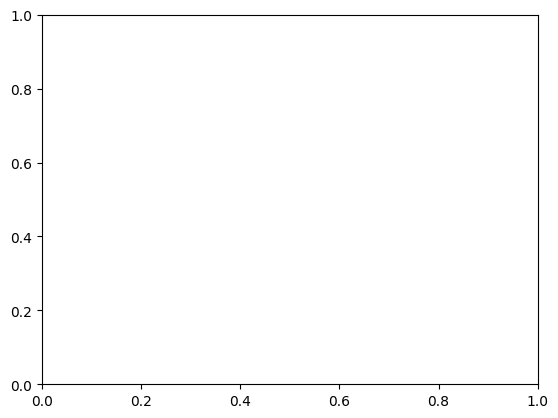

In [46]:
import matplotlib.pyplot as plt
import numpy as np

phase = adata.obs["ccPhase"].values  # categorical labels
pc1 = U[:, 0]

# Get unique phases
unique_phases = np.unique(phase)

for p in unique_phases:
    mask = phase == p
    plt.scatter(pc1[mask], np.zeros_like(pc1[mask]), 
                label=p, s=5)

plt.yticks([])  # Hide meaningless y-axis
plt.xlabel("PC1")
plt.legend(title="Cell Cycle Phase")
plt.show()

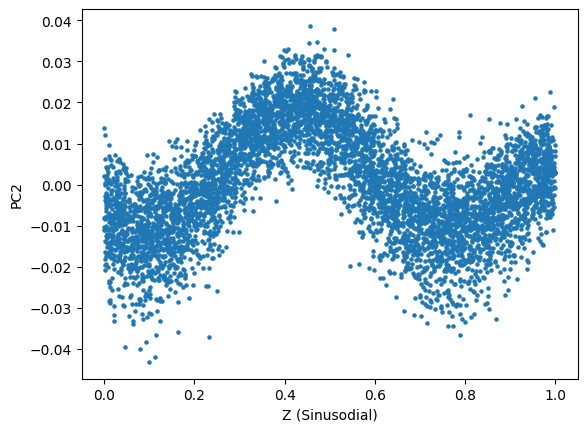

In [38]:
z = adata.obsm['ground_truth_z'][:,1]
plt.scatter(z, U[:, 1], s=5)
plt.xlabel("Z (Sinusodial)")
plt.ylabel("PC2")
plt.show()

In [50]:
codes

array([1, 1, 4, ..., 0, 4, 2], dtype=int8)

In [57]:
np.array(U[:,0]).squeeze().shape

(1477,)

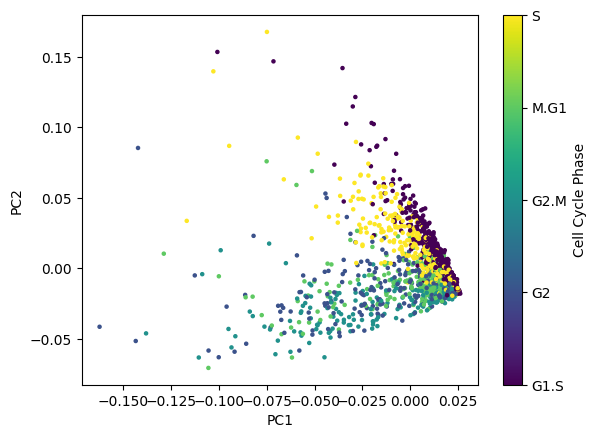

In [58]:
import pandas as pd

phase = pd.Categorical(adata.obs["ccPhase"])
codes = phase.codes

sc = plt.scatter(np.array(U[:,0]).squeeze(), np.array(U[:,1]).squeeze(), s=5, c=codes)

cbar = plt.colorbar(sc)
cbar.set_ticks(range(len(phase.categories)))
cbar.set_ticklabels(phase.categories)
cbar.set_label("Cell Cycle Phase")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [40]:
z.shape

(6000,)

Text(0, 0.5, 'PC1')

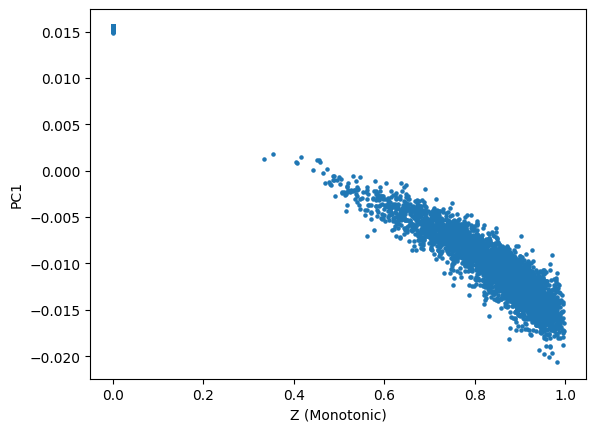

In [41]:
mask_monotonic = np.zeros(adata.n_vars)
mask_monotonic[adata.var["gene_symbols"].isin(genes_process_monotonic)] = 1
monotone_genes_potentially = adata.X[:,mask_monotonic.astype(bool)]

X = monotone_genes_potentially
X = X - X.mean(axis=0)

U, S, Vt = np.linalg.svd(X, full_matrices=False)
pc1 = U[:, 0]

z = adata.obsm['ground_truth_z'][:,0]
plt.scatter(z, pc1, s=5)
plt.xlabel("Z (Monotonic)")
plt.ylabel("PC1")

### Configure Save Paths

In [36]:
epoch_embeddings_save_path = "/Users/jeromecho/onedrive/Thesis/thesis/results/benchmarking/synthetic/02_03_experiment_set_1/celluntangler_r2_e10"
visualize_information={}
# The epochs to save the intermediate embeddings for
visualize_information["epochs"]=[i for i in range(0, 500, 50)] 
visualize_information["x"]=x
visualize_information["y"]=y
visualize_information["embeddings_save_path"]=epoch_embeddings_save_path
visualize_information["model_name"]=config.model_name
visualize_information["device"]=config.device

### Model Creation

In [37]:
use_gpu = False
if use_gpu:
  print("Using GPU")
  config.device = torch.device("cuda")
else:
  print("Using CPU")
  config.device = torch.device("cpu")

Using CPU


In [38]:
torch.set_default_dtype(torch.float64)

In [39]:
model = NBVAE(h_dim=config.h_dim,
              components=components,
              mask=mask,
              dataset=dataset,
              config=config).to(config.device)

Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
RotatedHyperbolicComponent(R^3)


### Training

In [40]:
trainer = Trainer(model)

optimizer = trainer.build_optimizer(learning_rate=config.learning_rate,
                                        fixed_curvature=config.fixed_curvature,
                                        use_adamw=config.use_adamw,
                                        weight_decay=config.weight_decay)

betas = utils.linear_betas(config.start,
                           config.end,
                           end_epoch=config.end_epoch,
                           epochs=config.epochs)


trainer.train_epochs(optimizer=optimizer,
                       train_data=train_loader,
                       betas=betas,
                       likelihood_n=0,
                       max_epochs=config.max_epochs,
                       visualize_information=visualize_information)

initialized early stopper
	TrainEpoch 0:	

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


{'bce': -1617.202, 'kl': 13.907, 'elbo': -1631.109, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_r2/curvature': -2.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 1:	{'bce': -1165.85, 'kl': 8.216, 'elbo': -1174.066, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_r2/curvature': -2.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 2:	{'bce': -1141.959, 'kl': 8.039, 'elbo': -1149.998, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_r2/curvature': -2.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 3:	{'bce': -1134.439, 'kl': 9.163, 'elbo': -1143.602, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_r2/curvature': -2.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 4:	{'bce': -1112.658, 'kl': 12.487, 'elbo': -1125.145, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_r2/curvature': -2.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 5:	{'bce': -1083.586, 'kl': 12.746, 'elbo': -1096.332, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 

### Saving Embeddings

In [41]:
embeddings_save_path = epoch_embeddings_save_path

In [42]:
checkpoint = torch.load(
    os.path.join(embeddings_save_path,  f"{model_name}_best_model.pt"),
    map_location=config.device
)
model.load_state_dict(checkpoint["model_state"])
model.eval()

NBVAE(
  (components): ModuleList(
    (0): RotatedHyperbolicComponent(R^3)
    (1): EuclideanComponent(R^10)
  )
  (encoder): Sequential(
    (0): Linear(in_features=1000, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): GELU(approximate='none')
  )
  (decoder): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): GELU(approximate='none')
  )
  (fc_mu): Linear(in_features=128, out_features=1000, bias=True)
  (fc_sigma): Linear(in_features=128, out_features=1000, bias=True)
)

In [43]:
a = model(torch.log1p(torch.tensor(x, device=config.device)), torch.tensor(y, device=config.device))
np.savetxt(os.path.join(embeddings_save_path, f'{model_name}_all_encode_v63_z_params_best.txt'), a[4].detach().to(torch.device("cpu")).numpy())

### Analysis

In [44]:
gene_expression_matrix_path = epoch_embeddings_save_path

In [45]:
embeddings = np.loadtxt(os.path.join(embeddings_save_path, f'{model_name}_all_encode_v63_z_params_best.txt'))
component_embeddings = split_embeddings(model_name, embeddings)
for c in component_embeddings:
    adata.obsm[c] = component_embeddings[c]

r2 3
e10 10


In [46]:
embeddings_save_path

'/Users/jeromecho/onedrive/Thesis/thesis/results/benchmarking/synthetic/02_03_experiment_set_1/celluntangler_r2_e10'

#### Visualization of Component 1 (E2) - Note: this work exists in exclusive OR with step immediately below

In [47]:
embeddings_key = "component1_e2"
desired_obs = 'pert'

visualize_2d(
    embeddings=adata.obsm[embeddings_key],
    adata = adata, 
    annotation = desired_obs,
    show_legend = False
)

KeyError: 'component1_e2'

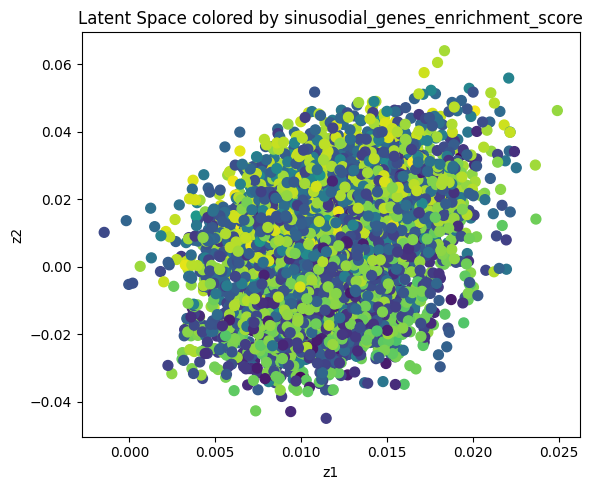

In [54]:
embeddings_key = "component1_e2"
desired_obs = 'sinusodial_genes_enrichment_score'

visualize_2d(
    embeddings=adata.obsm[embeddings_key],
    adata = adata, 
    annotation = desired_obs,
    show_legend = False
)         

In [58]:
adata.obsm['ground_truth_z']

array([[0.79443645, 0.4648784 ],
       [0.82671281, 0.58044714],
       [0.63714091, 0.7116145 ],
       ...,
       [0.7631631 , 0.63902738],
       [0.        , 0.87368919],
       [0.        , 0.20463322]])

In [59]:
embeddings = adata.obsm[embeddings_key]

In [50]:
adata.obs["z_sinusoidal"] = adata.obsm['ground_truth_z'][:,1]

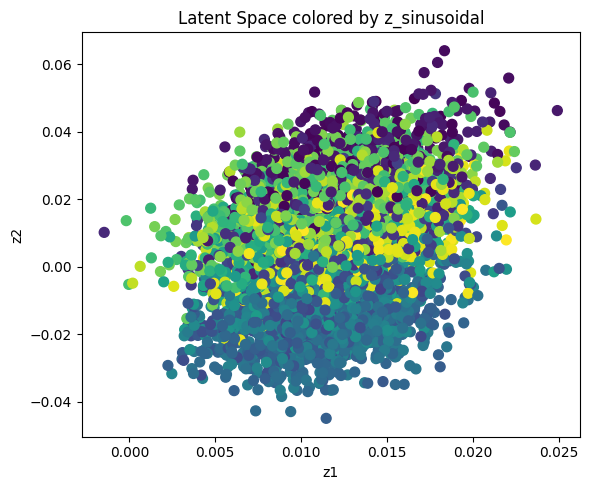

In [65]:
embeddings_key = "component1_e2"
desired_obs = "z_sinusoidal"

visualize_2d(
    embeddings=adata.obsm[embeddings_key],
    adata = adata, 
    annotation = desired_obs,
    show_legend = False
)         

(array([  2.,   7.,  19.,  66.,  92., 103., 142., 143., 163., 128., 131.,
        115., 129., 105.,  84.,  87.,  96.,  86.,  68.,  75.,  74.,  72.,
         68.,  78.,  65.,  84.,  81., 111., 106.,  98., 102., 119., 132.,
        151., 152., 186., 231., 295., 324., 353., 365., 411., 281., 154.,
         53.,  10.,   1.,   0.,   1.,   1.]),
 array([-1.57735391, -1.51154259, -1.44573128, -1.37991997, -1.31410866,
        -1.24829734, -1.18248603, -1.11667472, -1.05086341, -0.98505209,
        -0.91924078, -0.85342947, -0.78761816, -0.72180684, -0.65599553,
        -0.59018422, -0.52437291, -0.45856159, -0.39275028, -0.32693897,
        -0.26112766, -0.19531634, -0.12950503, -0.06369372,  0.00211759,
         0.06792891,  0.13374022,  0.19955153,  0.26536284,  0.33117416,
         0.39698547,  0.46279678,  0.52860809,  0.59441941,  0.66023072,
         0.72604203,  0.79185334,  0.85766466,  0.92347597,  0.98928728,
         1.05509859,  1.12090991,  1.18672122,  1.25253253,  1.31834384,
 

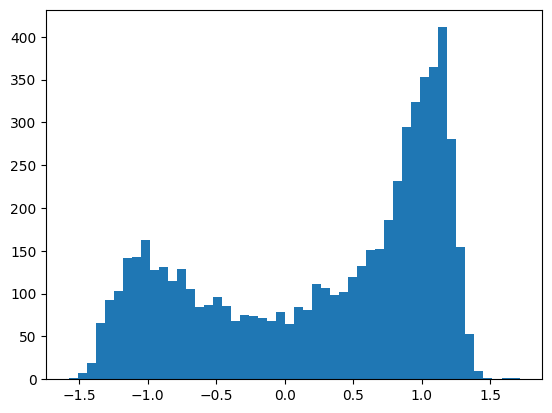

In [68]:
theta = np.arctan2(embeddings[:,1], embeddings[:,0])
plt.hist(theta, bins=50)

#### Visualization of Component 1 (R2)

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/CellUntangler/src/visualization/visualization_functions.py:266: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', bbox_to_anchor=bbox_to_anchor)


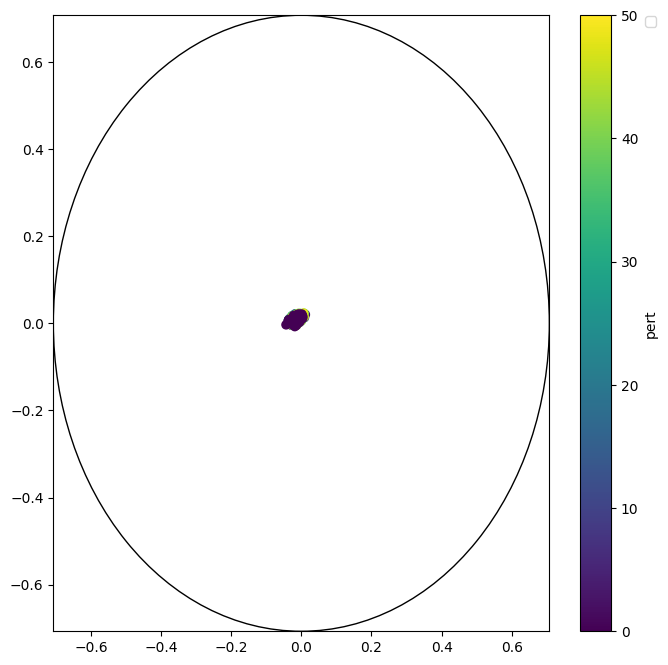

In [48]:
embeddings_key = "component1_r2"
desired_obs = 'pert'
desired_obs_all = adata.obs[desired_obs]
legend_coordinates = (1.23,1.01)
fig = visualize_poincare_from_lorentz(adata.obsm[embeddings_key],
                       desired_obs_all,
                       curvature=-2,
                      embedding_type='continuous',
                       cmap=plt.cm.viridis,
                       cat_colors=None,
                      grid_lines=True,
                      c_bar_label=desired_obs,
                      bbox_to_anchor=legend_coordinates)

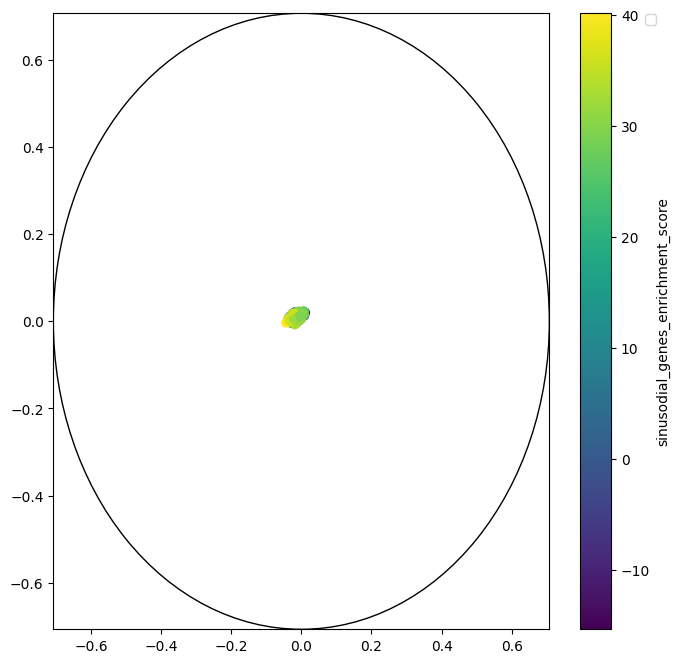

In [49]:
embeddings_key = "component1_r2"
desired_obs = 'sinusodial_genes_enrichment_score'
desired_obs_all = adata.obs[desired_obs]
legend_coordinates = (1.23,1.01)
fig = visualize_poincare_from_lorentz(adata.obsm[embeddings_key],
                       desired_obs_all,
                       curvature=-2,
                      embedding_type='continuous',
                       cmap=plt.cm.viridis,
                       cat_colors=None,
                      grid_lines=True,
                      c_bar_label=desired_obs,
                      bbox_to_anchor=legend_coordinates)

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/CellUntangler/src/visualization/visualization_functions.py:266: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', bbox_to_anchor=bbox_to_anchor)


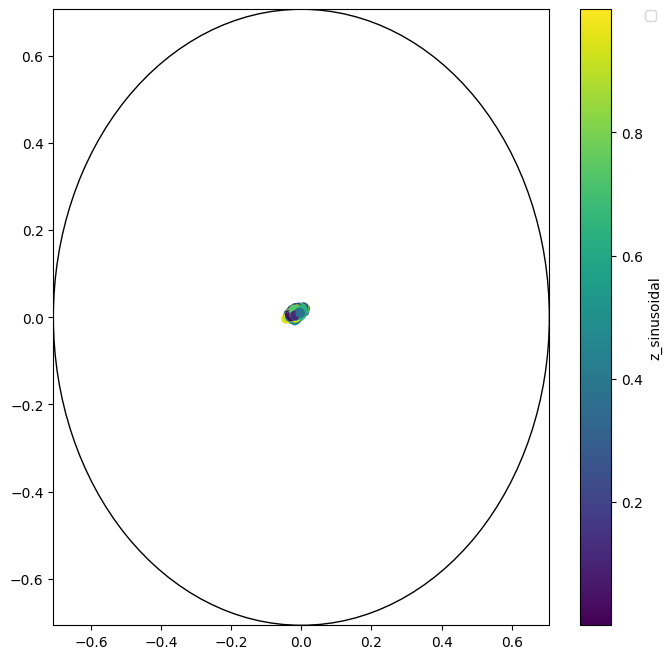

In [51]:
embeddings_key = "component1_r2"
desired_obs = 'z_sinusoidal'
desired_obs_all = adata.obs[desired_obs]
legend_coordinates = (1.23,1.01)
fig = visualize_poincare_from_lorentz(adata.obsm[embeddings_key],
                       desired_obs_all,
                       curvature=-2,
                      embedding_type='continuous',
                       cmap=plt.cm.viridis,
                       cat_colors=None,
                      grid_lines=True,
                      c_bar_label=desired_obs,
                      bbox_to_anchor=legend_coordinates)

Text(0.5, 1.0, 'Sinusodial Genes Enrichment Score Distribution')

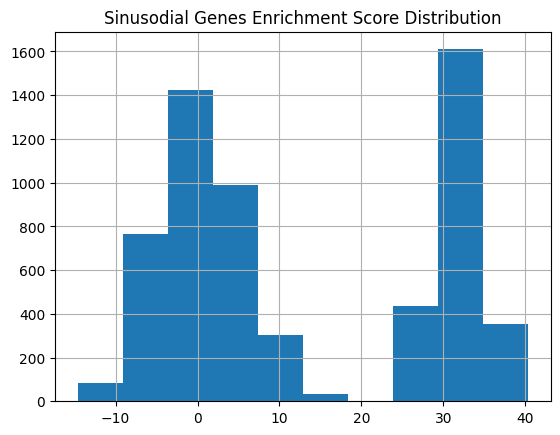

In [62]:
ax = adata.obs["sinusodial_genes_enrichment_score"].hist()
ax.set_title("Sinusodial Genes Enrichment Score Distribution")

#### Visualization of Component 2 (E2)

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


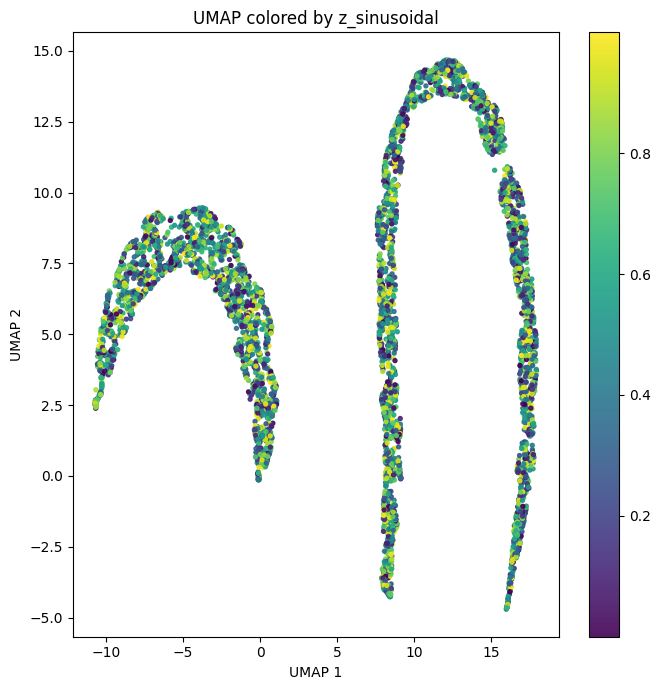

In [66]:
embeddings_key = "component2_e10"
desired_obs = 'z_sinusoidal'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    point_size=8,
    alpha=0.9,
    figsize=(7,7),
    show_legend=False
)

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


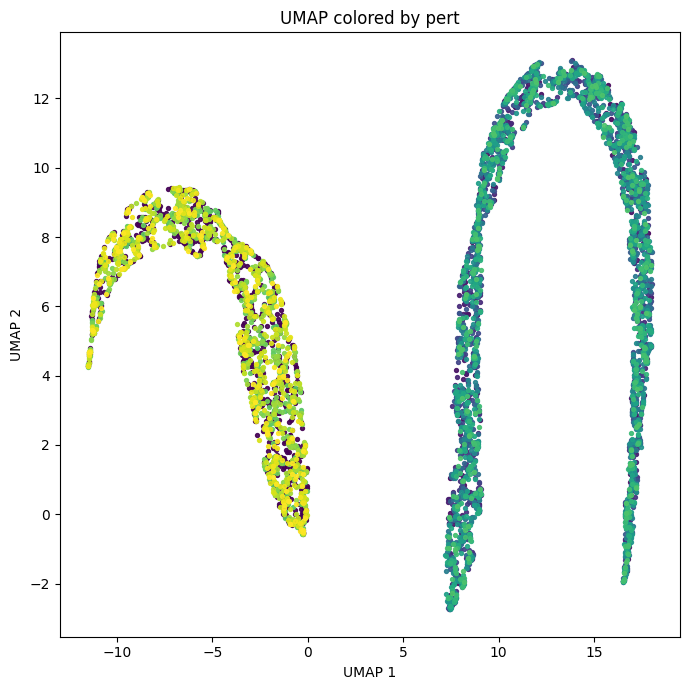

In [63]:
embeddings_key = "component2_e10"
desired_obs = 'pert'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    point_size=8,
    alpha=0.9,
    figsize=(7,7),
    show_legend=False
)

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


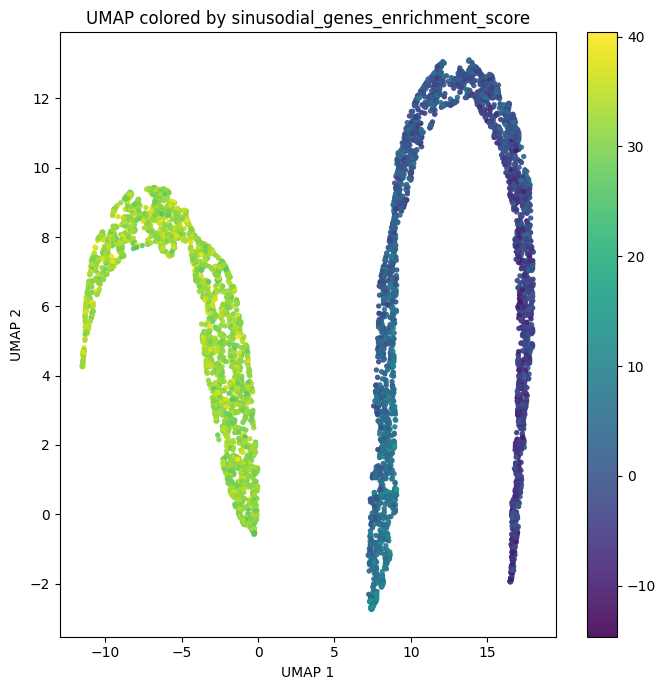

In [64]:
embeddings_key = "component2_e10"
desired_obs = 'sinusodial_genes_enrichment_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    point_size=8,
    alpha=0.9,
    figsize=(7,7),
    show_legend=False
)